# Credit Card Customer Segmentation
**Dataset:** CC General — 8.950 clientes · 18 variáveis comportamentais
**Link do Kaggle:**

---

## Objetivo

Identificar perfis de clientes de cartão de crédito com base em comportamento financeiro real,
traduzindo os segmentos em estratégias de marketing de crédito acionáveis.

---


## Fases CRISP-DM

- Entendimento do negócio  
- Entendimento dos dados  
- Preparação  
- Modelagem  
- Avaliação  
- Implantação  

---

## Variáveis do dataset

| Grupo | Variáveis |
|-------|-----------|
| Saldo e crédito | `BALANCE`, `CREDIT_LIMIT` |
| Compras | `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES` |
| Saques | `CASH_ADVANCE` |
| Frequências | `BALANCE_FREQUENCY`, `PURCHASES_FREQUENCY`, `ONEOFF_PURCHASES_FREQUENCY`, `PURCHASES_INSTALLMENTS_FREQUENCY`, `CASH_ADVANCE_FREQUENCY` |
| Transações | `PURCHASES_TRX`, `CASH_ADVANCE_TRX` |
| Pagamentos | `PAYMENTS`, `MINIMUM_PAYMENTS`, `PRC_FULL_PAYMENT` |
| Relacionamento | `TENURE` |

In [1]:
import sys, os
import pandas as pd 
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score


import statsmodels.api as sm
from scipy import stats

from utils.eda_utils import *


PALETA = ['#7F77DD', '#1D9E75', '#D85A30', '#378ADD', '#BA7517', '#D4537E']



In [2]:
df = pd.read_csv('../data/cc_general.csv', sep=',')


print(f'Shape: {df.shape}')
print(f'\nColunas:')
print(df.dtypes)
print(f'\nThe dataset has {df.shape[0]} rows and {df.shape[1]} columns.')


Shape: (8950, 18)

Colunas:
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

The dataset has 8950 rows and 18 columns.


In [3]:
resumo(df)

,dtype,nulos,% nulos,unicos
MINIMUM_PAYMENTS,float64,313,3.50,8636
CREDIT_LIMIT,float64,1,0.01,205
BALANCE,float64,0,0.00,8871
CUST_ID,object,0,0.00,8950
BALANCE_FREQUENCY,float64,0,0.00,43
PURCHASES,float64,0,0.00,6203
CASH_ADVANCE,float64,0,0.00,4323
PURCHASES_FREQUENCY,float64,0,0.00,47
ONEOFF_PURCHASES,float64,0,0.00,4014
INSTALLMENTS_PURCHASES,float64,0,0.00,4452


In [4]:
print('Duplicadas por CUST_ID:', df['CUST_ID'].duplicated().sum())
print('Linhas completamente duplicadas:', df.duplicated().sum())

Duplicadas por CUST_ID: 0
Linhas completamente duplicadas: 0


In [5]:
features_valor = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'
]


features_freq = [
    'BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT'
]

features_contagem = ['PURCHASES_TRX', 'CASH_ADVANCE_TRX', 'TENURE']

print('Variáveis de valor (R$):', features_valor)
print('Variáveis de frequência (0-1):', features_freq)
print('Variáveis de contagem:', features_contagem)


Variáveis de valor (R$): ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
Variáveis de frequência (0-1): ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT']
Variáveis de contagem: ['PURCHASES_TRX', 'CASH_ADVANCE_TRX', 'TENURE']


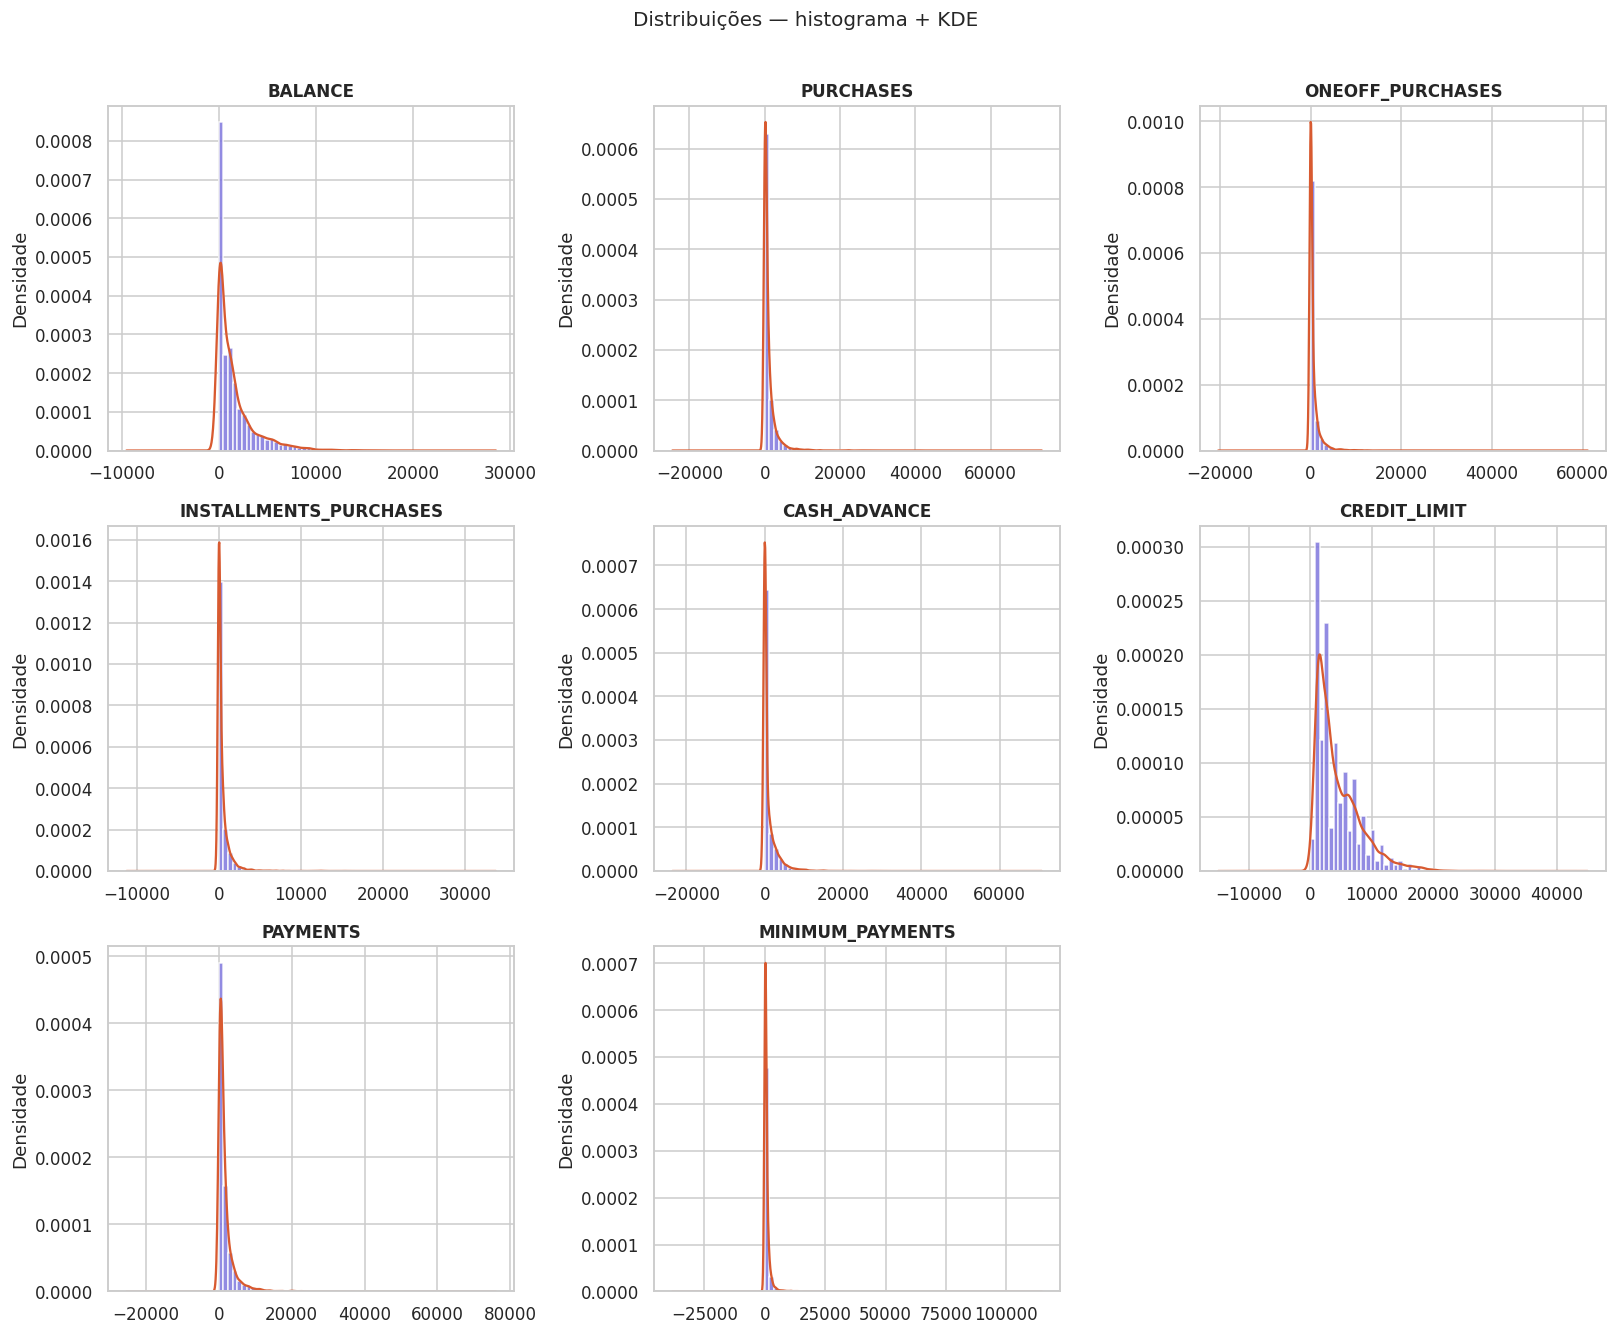

In [6]:
plot_histogramas(df, features_valor)

**Histogramas — Variáveis de valor**

A assimetria positiva em todas as variáveis monetárias indica que **poucos clientes concentram alto volume financeiro**, sugerindo uma base com cauda longa de alto valor — padrão comum em carteiras de crédito.

- **`CASH_ADVANCE`**: a concentração em zero revela que o saque é um comportamento de nicho. Quando ocorre, tende a ser intenso — sinalizando clientes que usam o crédito como fonte de liquidez, não como conveniência de compra
- **`PURCHASES`**: poucos clientes realizam compras de alto volume, mas são os que mais geram receita via intercâmbio e juros parcelados — perfil de alto valor estratégico
- **`MINIMUM_PAYMENTS`**: dispersão elevada indica heterogeneidade no comportamento de pagamento — parte da base paga pouco do saldo, acumulando dívida rotativa

> **Decisão de modelagem:** aplicar `log1p` antes do PCA e K-means para evitar que esses outliers de alto valor distorçam as distâncias euclidianas e dominem os componentes principais.

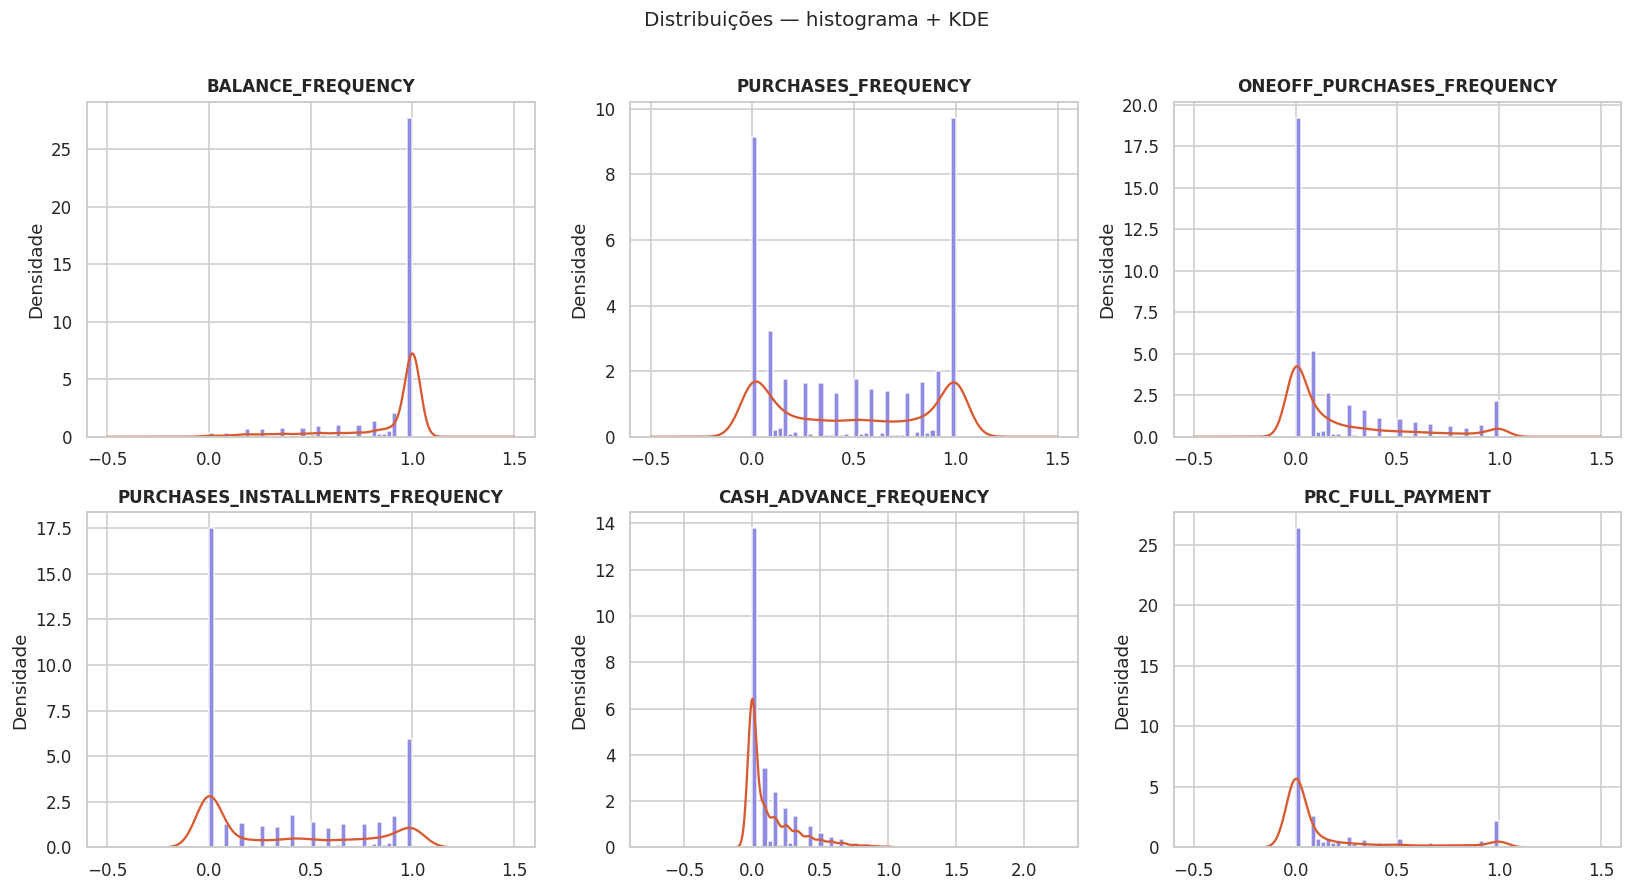

In [7]:
plot_histogramas(df, features_freq)

**Histogramas — Variáveis de frequência**

- **`PURCHASES_FREQUENCY`**: distribuição **bimodal** — existem dois grupos comportamentais distintos: clientes que nunca compram (≈ 0) e clientes que compram em quase todos os meses (≈ 1). Essa separação é o **principal sinal de segmentação** do dataset — indica que parte da base não usa o cartão para compras, apenas mantém saldo ou saca
- **`BALANCE_FREQUENCY`**: concentrada próxima a 1 — a maioria dos clientes tem saldo rotativo ativo, o que representa receita de juros para o banco
- **`PRC_FULL_PAYMENT`**: concentrada em zero — poucos clientes pagam a fatura integralmente. Isso é ambivalente: por um lado é risco de inadimplência, por outro é receita de juros
- **`CASH_ADVANCE_FREQUENCY`**: concentrada em zero — confirma que saque é comportamento de nicho, mas quem o faz tende a fazê-lo com frequência (perfil de risco)

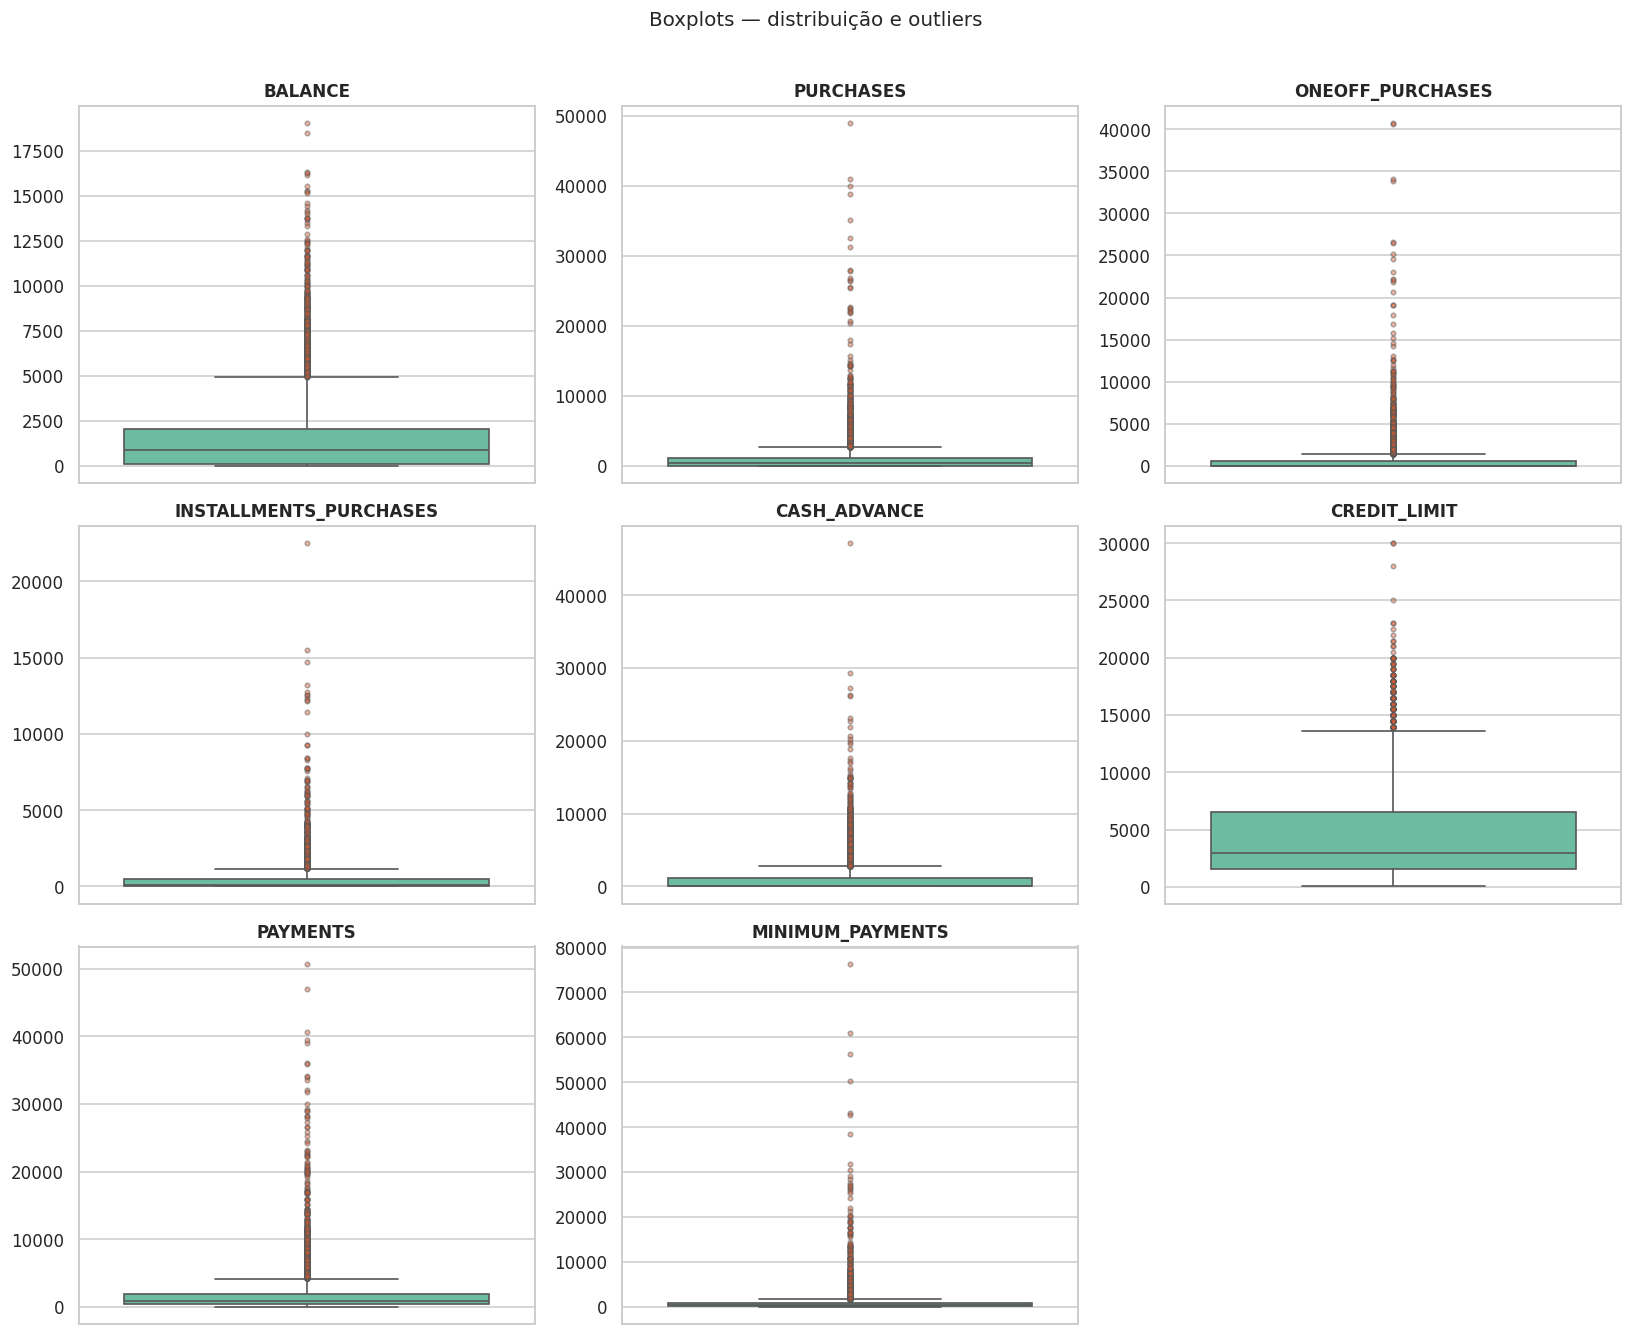

In [8]:
plot_boxplots(df, features_valor)

**Outliers nas variáveis de valor**

- CASH_ADVANCE  
  - Intensidade: Alta  
  - Interpretação: Clientes com alta dependência de saque — potencial inadimplência, uso do crédito como renda  

- PURCHASES  
  - Intensidade: Moderada  
  - Interpretação: Compradores de alto volume — segmento de alto valor, potencial para produtos premium  

- MINIMUM_PAYMENTS  
  - Intensidade: Alta  
  - Interpretação: Pagamento mínimo recorrente indica acúmulo de dívida — risco de crédito latente  

- BALANCE  
  - Intensidade: Moderada  
  - Interpretação: Saldo elevado persistente — pode indicar uso intenso do rotativo ou dificuldade de quitação  

> **Ação:** manter os outliers e aplicar `log1p` para comprimir a escala sem descartar informação.

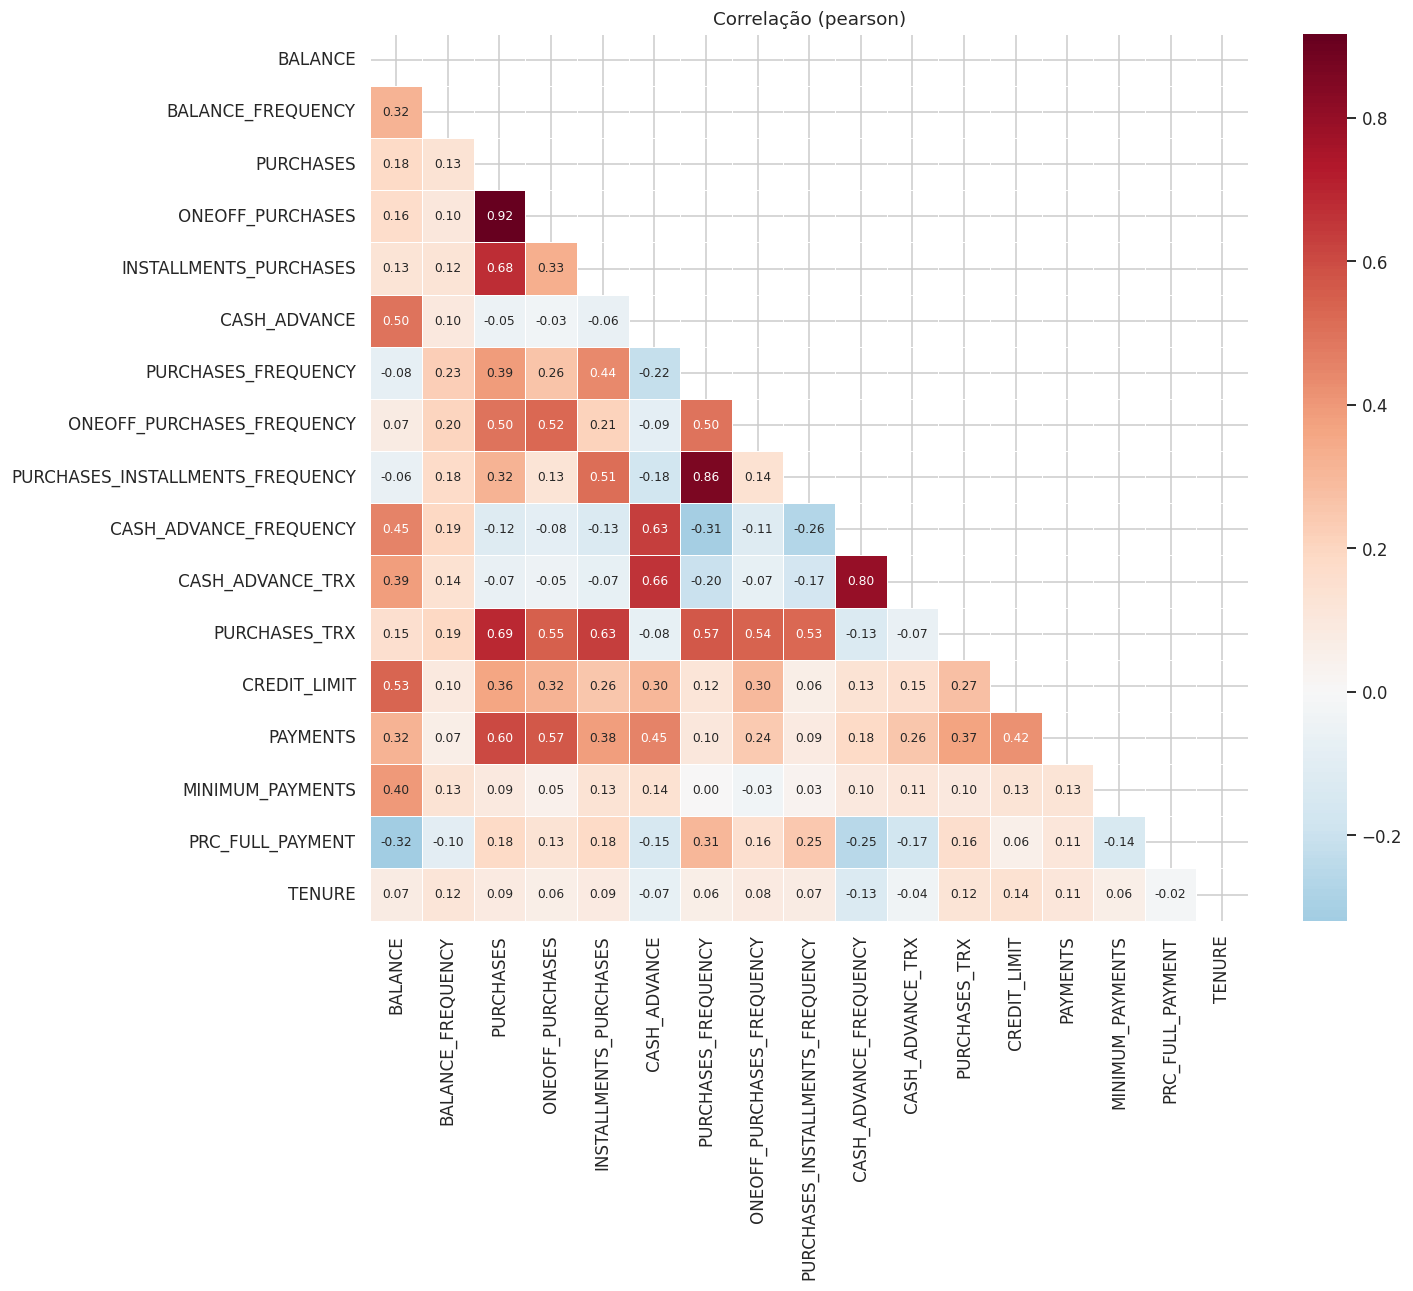

In [9]:
numericas = df.select_dtypes(include='number').columns.tolist()
plot_correlacao(df, features=numericas, metodo='pearson')

**Mapa de correlação**

- Multicolinearidade identificada → oportunidade para uso de PCA  
  - Variáveis altamente correlacionadas carregam informação redundante  
  - PCA extrai os eixos de maior variação e elimina essa redundância  

- PURCHASES ↔ ONEOFF_PURCHASES (r ≈ 0.92)  
  - Compras à vista dominam o comportamento de compra total  

- PURCHASES_TRX ↔ PURCHASES_FREQUENCY (r ≈ 0.86)  
  - Quem compra com frequência, compra muitas vezes — engajamento consistente  

- PURCHASES_INSTALLMENTS_FREQUENCY ↔ PURCHASES_FREQUENCY (r ≈ 0.79)  
  - Clientes frequentes preferem parcelamento — oportunidade para produtos de parcelamento  

- CASH_ADVANCE ↔ CASH_ADVANCE_FREQUENCY (r ≈ 0.63)  
  - Quem saca, saca com regularidade — comportamento estrutural, não pontual  

> **Conclusão:** o PCA é a escolha correta — reduz features correlacionadas a componentes independentes, melhorando a qualidade dos clusters e a interpretabilidade.

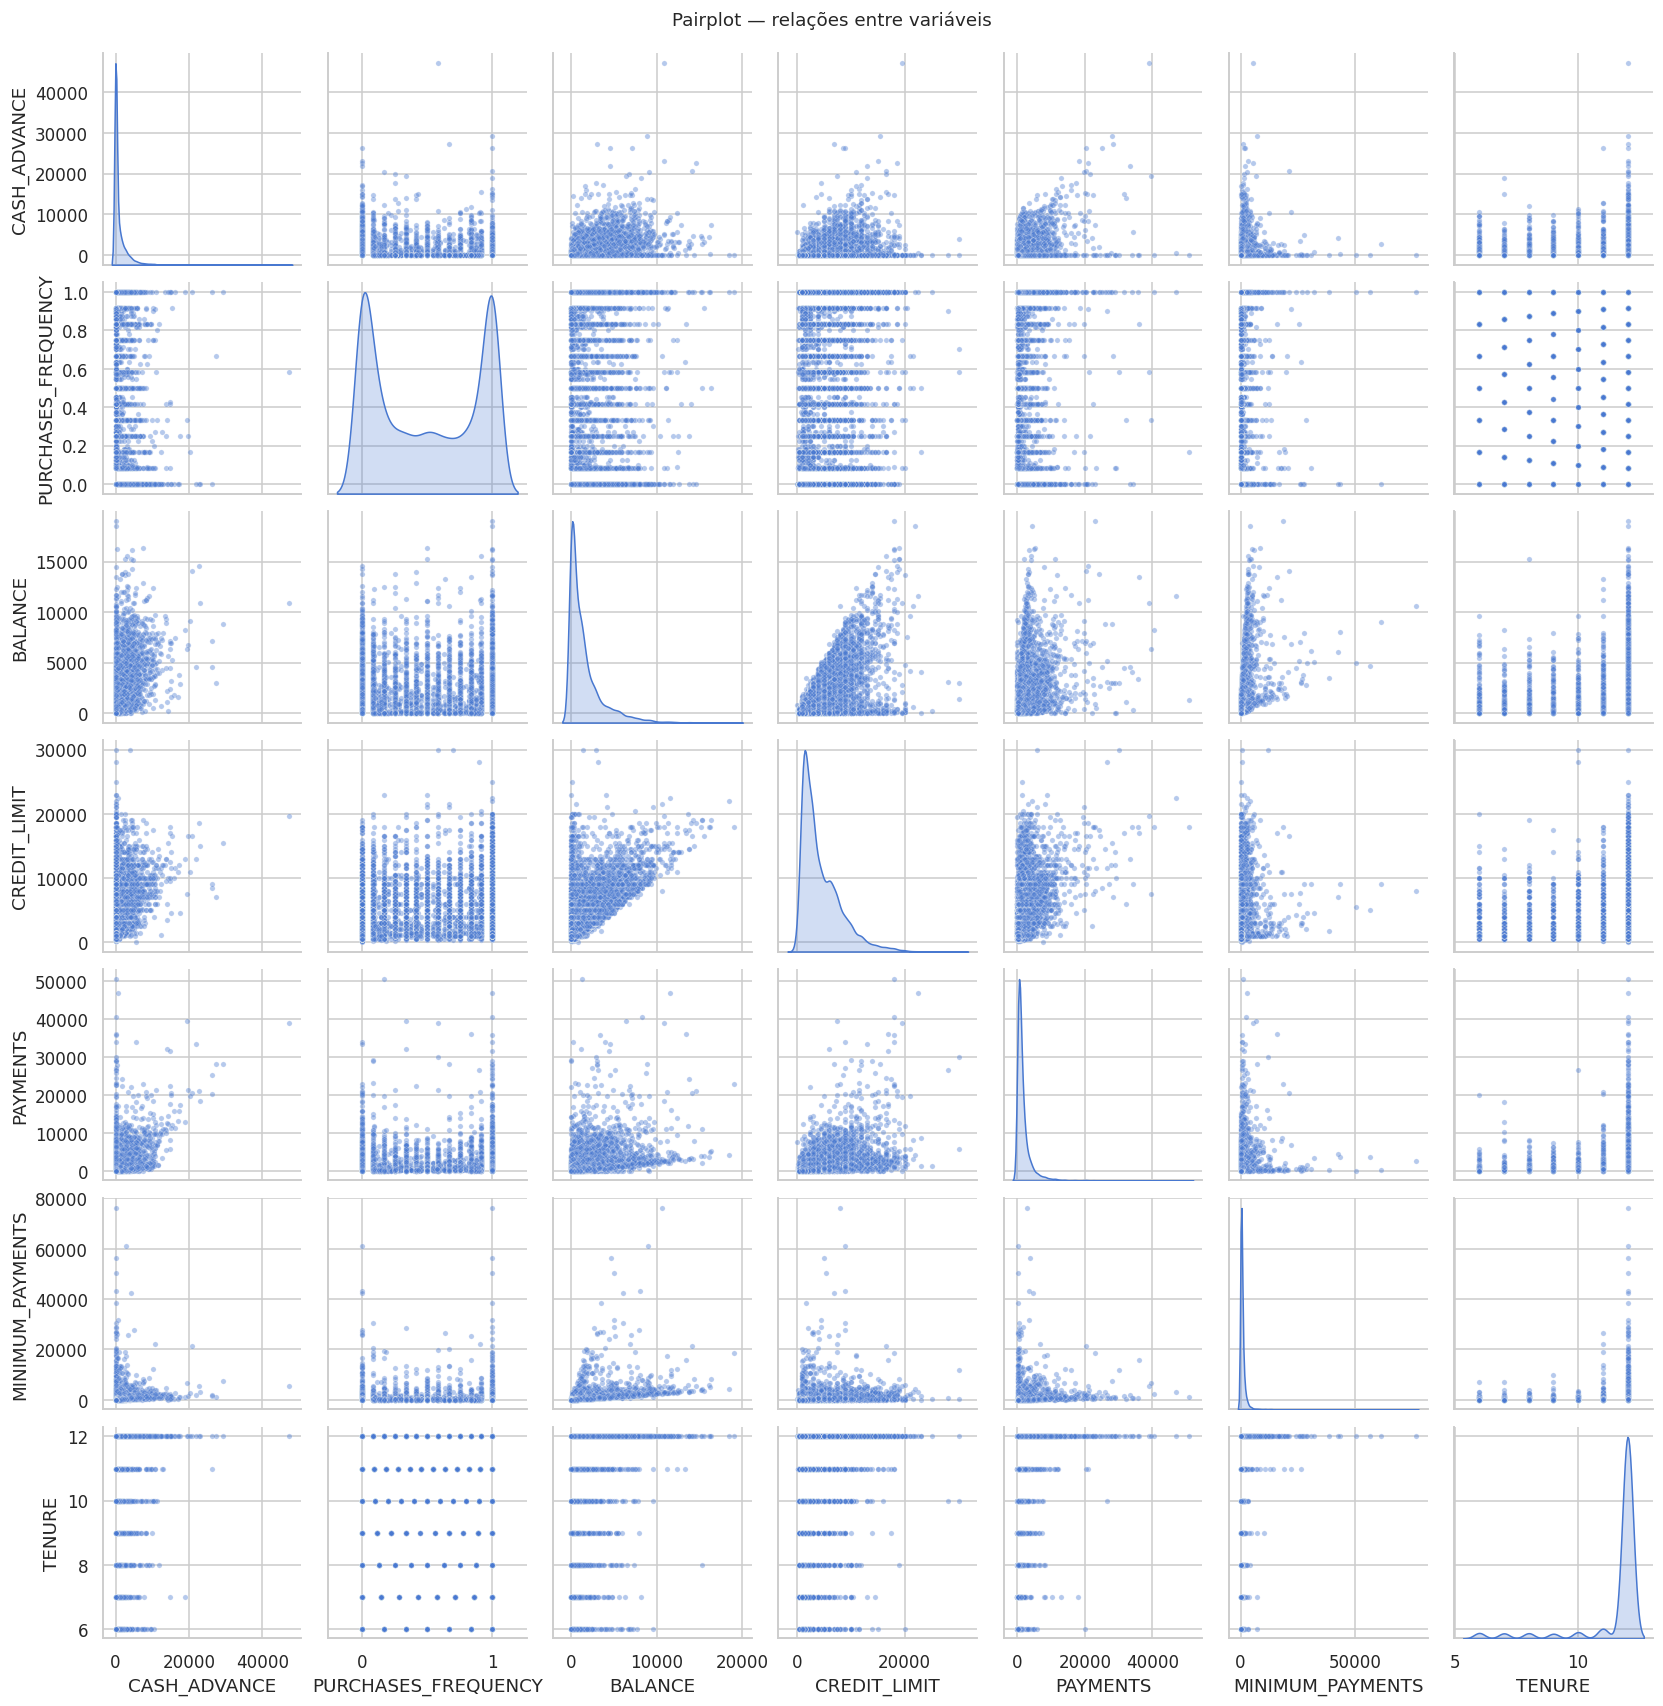

In [10]:

features_pair = [
    'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    'BALANCE', 'CREDIT_LIMIT',
    'PAYMENTS', 'MINIMUM_PAYMENTS', 'TENURE'
]
plot_pair(df, features=features_pair)

**Pairplot — Relações entre variáveis prioritárias**

- **`CASH_ADVANCE` vs `PURCHASES_FREQUENCY`**: nuvem sem padrão — clientes que sacam não são necessariamente os que menos compram. Saque e compra são **comportamentos financeiros independentes**, o que implica que os clusters criados serão ortogonais nessa dimensão — perfis distintos e não sobrepostos
- **`BALANCE` vs `CREDIT_LIMIT`**: tendência positiva leve — clientes com limite maior tendem a acumular mais saldo, sugerindo que o banco concede mais limite para quem já usa mais o produto
- **`TENURE`**: aparece como faixas horizontais discretas — concentrado em 12 meses, com pouca variação entre clientes. Isso indica que o período observado é homogêneo e `TENURE` terá peso menor no PCA
- **`MINIMUM_PAYMENTS`**: outliers extremos visíveis nos scatters — confirma que o comportamento de pagamento tem alta dispersão e deve ser tratado antes da modelagem

In [11]:
contar_outliers(df, features_valor)


,variavel,n_outliers,pct_outliers
0,CASH_ADVANCE,1030,11.51
1,ONEOFF_PURCHASES,1013,11.32
2,MINIMUM_PAYMENTS,841,9.74
3,INSTALLMENTS_PURCHASES,867,9.69
4,PAYMENTS,808,9.03
5,PURCHASES,808,9.03
6,BALANCE,695,7.77
7,CREDIT_LIMIT,248,2.77


---
## Fase 3 — Preparação dos dados

| Decisão | Justificativa |
|---------|---------------|
| Nulos → **mediana** | Robusta a outliers (média seria distorcida pelos valores extremos) |
| **log1p** em 7 variáveis | Comprime caudas longas → distribuições mais simétricas → PCA e K-means melhores |
| **CUST_ID** removido | Identificador sem valor preditivo |
| **StandardScaler** | PCA e K-means são sensíveis a escala — padronização obrigatória |
| `engagement_score` **excluído** | Feature derivada das frequências de compra — incluir criaria redundância e inflaria o PCA |

**Features para modelagem:** 14 variáveis (7 originais + 7 versões `_LOG`)

In [12]:
df_clean = df.copy()
df_clean.drop(columns=['CUST_ID'], errors='ignore', inplace=True)

nulos_antes = df_clean.isnull().sum()
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)
nulos_depois = df_clean.isnull().sum()


print(f'Nulos antes : {nulos_antes}')
print(f'Nulos depois: {nulos_depois}')
print(f'Shape final : {df_clean.shape}')

Nulos antes : BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
Nulos depois: BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHA

Colunas criadas: ['CASH_ADVANCE_LOG', 'BALANCE_LOG', 'PAYMENTS_LOG', 'MINIMUM_PAYMENTS_LOG', 'PURCHASES_LOG', 'ONEOFF_PURCHASES_LOG', 'INSTALLMENTS_PURCHASES_LOG']


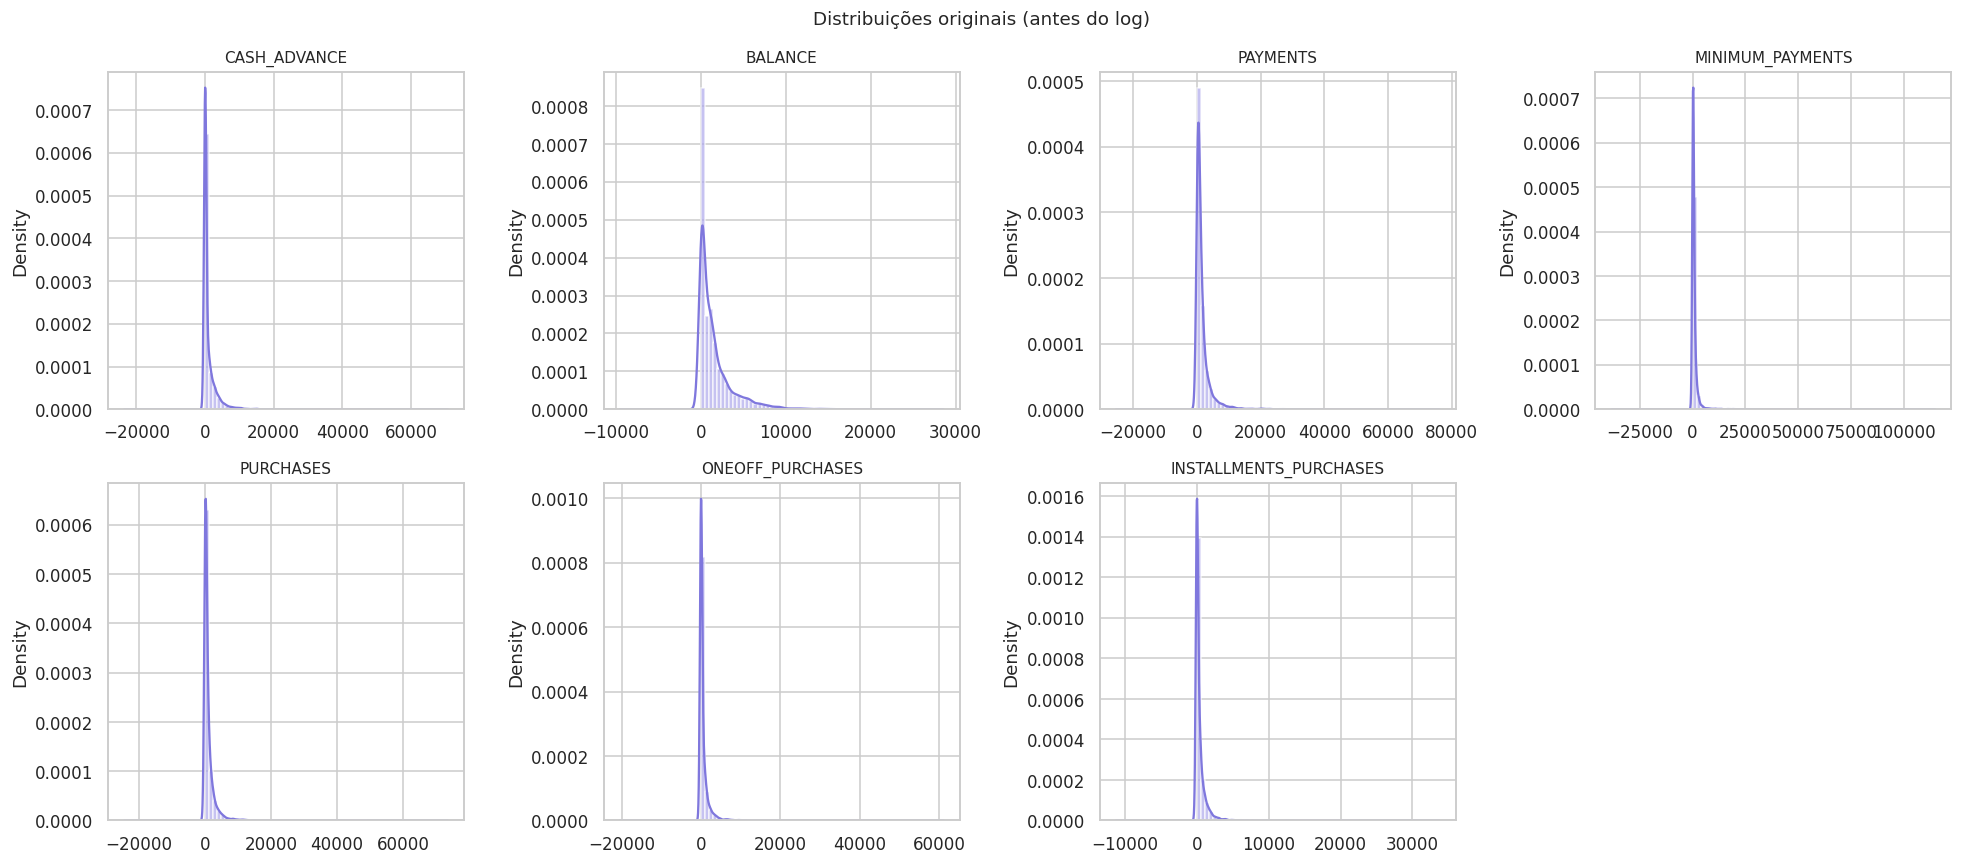

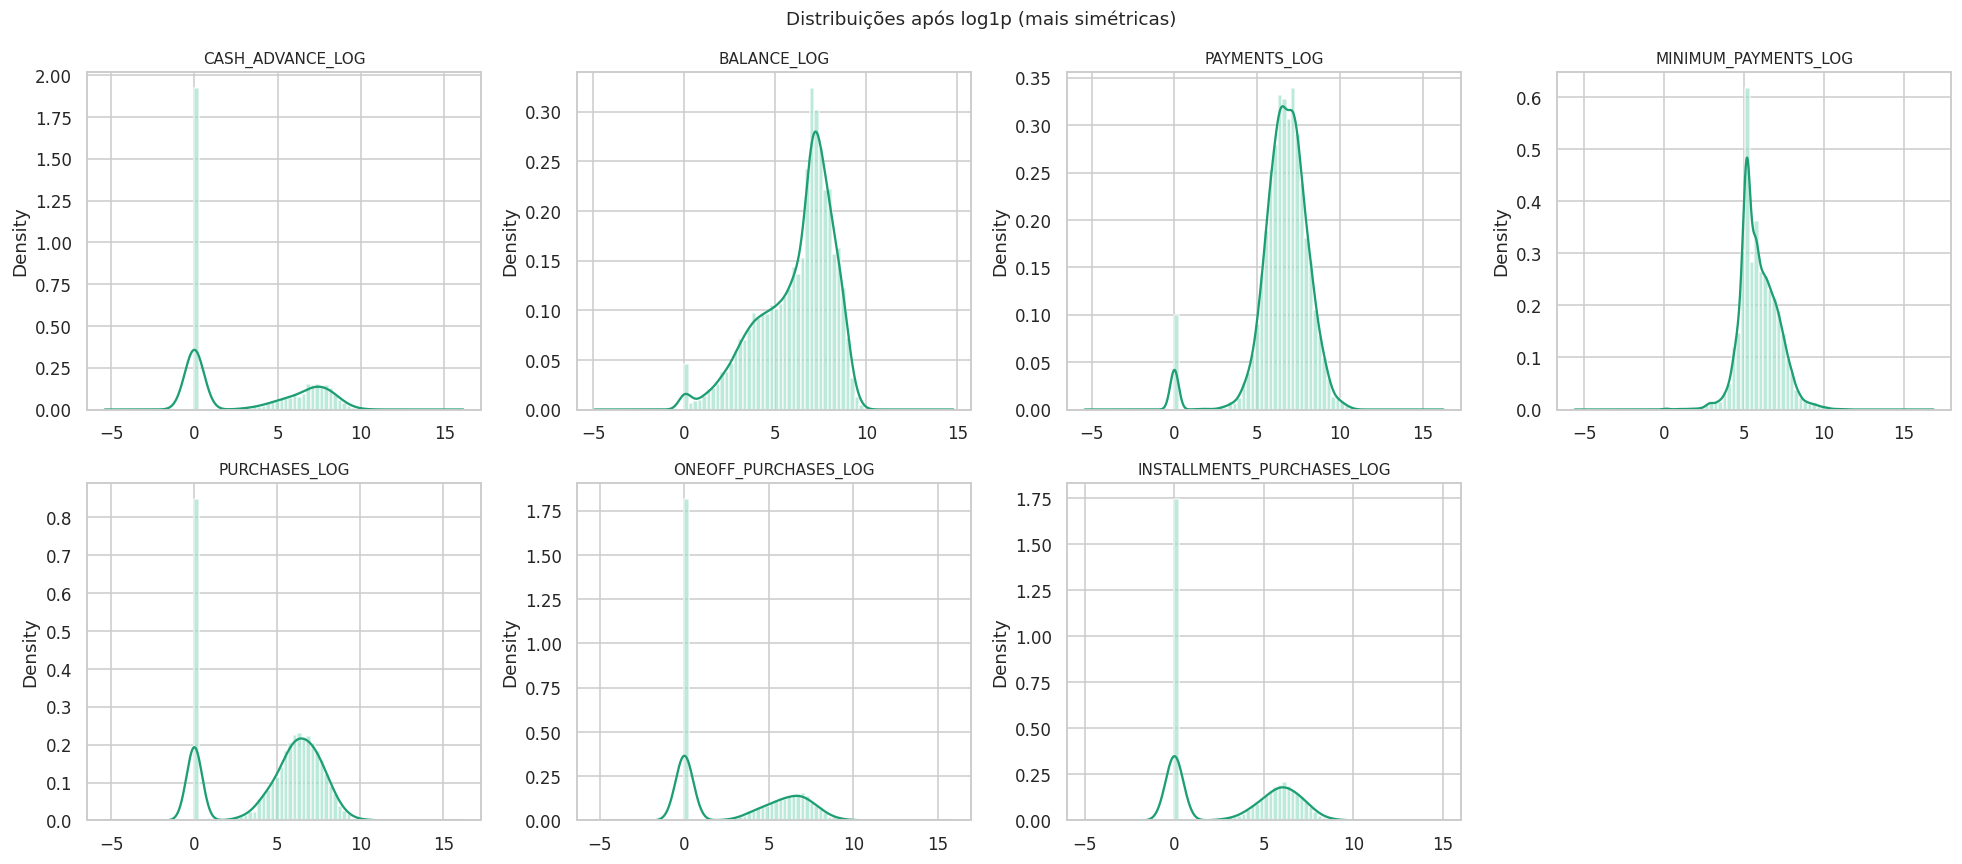

In [13]:
colunas_log = ['CASH_ADVANCE', 'BALANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS',
               'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES']

df_clean = aplicar_log(df_clean, colunas_log)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(colunas_log):
    axes[i].hist(df_clean[col], bins=40, color='#AFA9EC', alpha=0.7,
                 density=True, label='Original')
    df_clean[col].plot.kde(ax=axes[i], color='#7F77DD', linewidth=1.5)
    axes[i].set_title(col, fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Distribuições originais (antes do log)', fontsize=12)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(colunas_log):
    log_col = col + '_LOG'
    axes[i].hist(df_clean[log_col], bins=40, color='#9FE1CB', alpha=0.7,
                 density=True, label='Log')
    df_clean[log_col].plot.kde(ax=axes[i], color='#1D9E75', linewidth=1.5)
    axes[i].set_title(log_col, fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Distribuições após log1p (mais simétricas)', fontsize=12)
plt.tight_layout()
plt.show()


**Transformação log1p — antes vs depois**

A transformação `log1p(x) = log(1 + x)` foi aplicada nas 7 variáveis com cauda longa:

| Antes | Depois |
|-------|--------|
| Distribuição assimétrica à direita | Distribuição mais próxima da normal |
| Outliers extremos dominam a escala | Outliers comprimidos, escala equilibrada |
| PCA e K-means sensíveis aos valores altos | PCA e K-means operam em espaço mais uniforme |

> **Nota:** `log1p` evita `log(0)` — seguro para variáveis com zeros como `CASH_ADVANCE` e `PURCHASES`.

In [14]:
FEATURES_MODELO = [
    'BALANCE_LOG', 'PURCHASES_LOG', 'CASH_ADVANCE_LOG',
    'CREDIT_LIMIT', 'PAYMENTS_LOG', 'MINIMUM_PAYMENTS_LOG',
    'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
    'PURCHASES_TRX', 'CASH_ADVANCE_TRX',
    'PRC_FULL_PAYMENT', 'TENURE'
]

X = df_clean[FEATURES_MODELO].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features para modelagem: {len(FEATURES_MODELO)}')
print(FEATURES_MODELO)

Features para modelagem: 14
['BALANCE_LOG', 'PURCHASES_LOG', 'CASH_ADVANCE_LOG', 'CREDIT_LIMIT', 'PAYMENTS_LOG', 'MINIMUM_PAYMENTS_LOG', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'CASH_ADVANCE_TRX', 'PRC_FULL_PAYMENT', 'TENURE']


---
## Fase 4 — Modelagem · PCA

**Objetivo:** eliminar multicolinearidade entre as 14 features e reduzir dimensionalidade antes do K-means.

**Threshold escolhido:** 88% da variância explicada (`n_80 = argmax(acum >= 0.88) + 1`)



Componentes para 88% da variância: 8
Componentes para 95% da variância: 10



,PC,Variância explicada (%),Variância acumulada (%),Eigenvalue
0,PC1,30.65,30.65,4.2916
1,PC2,22.71,53.36,3.1793
2,PC3,8.99,62.34,1.2583
3,PC4,7.91,70.25,1.1071
4,PC5,6.58,76.83,0.9218
5,PC6,5.05,81.89,0.7072
6,PC7,4.73,86.61,0.6617
7,PC8,3.51,90.13,0.4921
8,PC9,3.33,93.45,0.4656
9,PC10,2.42,95.88,0.3394


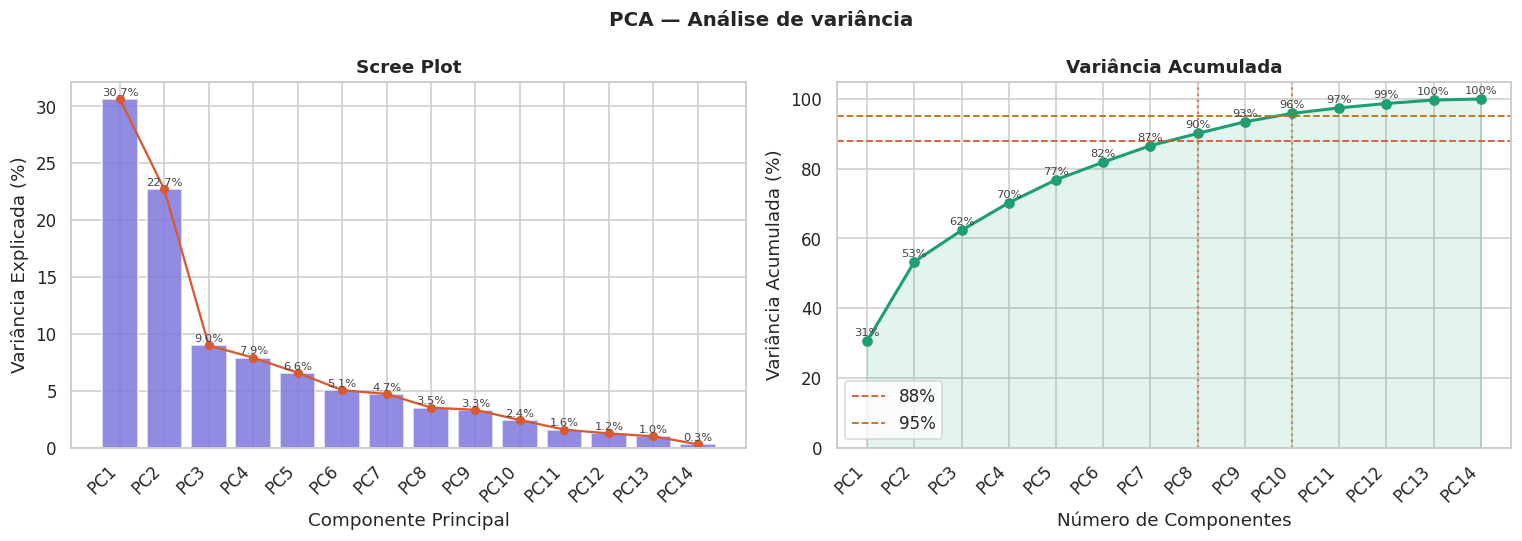

In [15]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_exp  = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

n_80 = int(np.argmax(var_acum >= 0.88)) + 1
n_95 = int(np.argmax(var_acum >= 0.95)) + 1

# Tabela de variância por componente
pca_table = pd.DataFrame({
    'PC'                     : [f'PC{i+1}' for i in range(len(var_exp))],
    'Variância explicada (%)' : (var_exp  * 100).round(2),
    'Variância acumulada (%)' : (var_acum * 100).round(2),
    'Eigenvalue'              : pca_full.explained_variance_.round(4),
})
print(f'Componentes para 88% da variância: {n_80}')
print(f'Componentes para 95% da variância: {n_95}')
print()
display(pca_table)

# Scree Plot + Variância Acumulada
x = range(1, len(var_exp) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree: barra + linha + anotação
axes[0].bar(x, var_exp * 100, color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].plot(x, var_exp * 100, 'o-', color='#D85A30', linewidth=1.5, markersize=5)
for xi, yi in zip(x, var_exp * 100):
    axes[0].text(xi, yi + 0.3, f'{yi:.1f}%', ha='center', fontsize=7.5, color='#444')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f'PC{i}' for i in x], rotation=45, ha='right')

# Variância acumulada: linha + fill + linhas de corte + anotação
axes[1].plot(x, var_acum * 100, 'o-', color='#1D9E75', linewidth=2, markersize=6)
axes[1].fill_between(x, var_acum * 100, alpha=0.12, color='#1D9E75')
axes[1].axhline(88, color='#D85A30', linestyle='--', linewidth=1.2, label='88%')
axes[1].axhline(95, color='#BA7517', linestyle='--', linewidth=1.2, label='95%')
axes[1].axvline(n_80, color='#D85A30', linestyle=':', alpha=0.7)
axes[1].axvline(n_95, color='#BA7517', linestyle=':', alpha=0.7)
for xi, yi in zip(x, var_acum * 100):
    axes[1].text(xi, yi + 1.5, f'{yi:.0f}%', ha='center', fontsize=7.5, color='#444')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].set_title('Variância Acumulada', fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([f'PC{i}' for i in x], rotation=45, ha='right')
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.suptitle('PCA — Análise de variância', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Scree Plot e Variância Acumulada**

O scree plot mostra a variância explicada por cada componente principal:

- As primeiras componentes capturam a maior parte da informação — há um 'cotovelo' indicando onde o ganho marginal diminui
- O threshold de **88%** foi escolhido como ponto de equilíbrio entre redução e preservação de informação

| Threshold | Componentes necessários | Informação preservada |
|-----------|------------------------|-----------------------|
| 80% | `n_80` (calculado acima) | Boa redução, alguma perda |
| **88%** | **`n_80` usado aqui** | **Equilíbrio escolhido** |
| 95% | `n_95` (calculado acima) | Pouca redução |

> O PCA com 2 componentes na célula seguinte é **exclusivo para visualização**. O K-means usará `n_80` componentes.

In [16]:
pca = PCA(n_components=2, random_state=42)
x_pca2 = pca.fit_transform(X_scaled)

pca_2 = pd.DataFrame(data=x_pca2, columns=['pca1','pca2'])
pca_2.head()


,pca1,pca2
0,0.137208,-2.443648
1,-2.790597,0.627621
2,1.341779,1.322141
3,-0.898818,-1.538977
4,-0.580539,-1.518004


**DataFrame de scores**

`pca1` e `pca2` são as coordenadas de cada cliente no espaço reduzido a 2 dimensões.

- Cada linha representa um cliente projetado no plano PC1 × PC2
- Clientes próximos no espaço PCA têm comportamento financeiro similar
- Este DataFrame será concatenado com os labels do K-means para visualizar os clusters

> **Lembrete:** `pca_2` tem 2 componentes (visualização). O K-means roda com `n_80` componentes.

---
## Fase 4 — Modelagem · K-means

**Pergunta de negócio (CRISP-DM Fase 1):** quais são os perfis de comportamento financeiro dos clientes?

**Pipeline completo:**
```
X (14 features) → StandardScaler → PCA (n_80 componentes, 88% variância) → K-means
```
**Escolha do K:** avaliada por três métricas — Elbow, Silhouette Score e Davies-Bouldin.

In [17]:
pca_km = PCA(n_components=n_80, random_state=42)
X_pca  = pca_km.fit_transform(X_scaled)

print(f'X_pca shape (entra no K-means): {X_pca.shape}')
print(f'pca_2 shape (só visualização) : {pca_2.shape}')


X_pca shape (entra no K-means): (8950, 8)
pca_2 shape (só visualização) : (8950, 2)


In [18]:
K_range = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in K_range:
    km  = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbs = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, lbs, sample_size=3000, random_state=42))
    db_scores.append(davies_bouldin_score(X_pca, lbs))

k_ideal = K_range[np.argmax(silhouettes)]

tabela_k = pd.DataFrame({
    'K'              : list(K_range),
    'Inércia'        : [round(v, 1) for v in inertias],
    'Silhouette'     : [round(v, 4) for v in silhouettes],
    'Davies-Bouldin' : [round(v, 4) for v in db_scores],
})
print(f'K ideal (melhor Silhouette): {k_ideal}')
display(tabela_k)


K ideal (melhor Silhouette): 2


,K,Inércia,Silhouette,Davies-Bouldin
0,2,84504.5,0.2525,1.5323
1,3,70796.9,0.2380,1.5363
2,4,63909.5,0.2142,1.5441
3,5,57846.4,0.2120,1.5343
4,6,52919.8,0.2230,1.4171
5,7,48546.7,0.2218,1.3645
6,8,45695.5,0.2200,1.3507
7,9,43155.6,0.2207,1.3609
8,10,41106.4,0.2078,1.4039


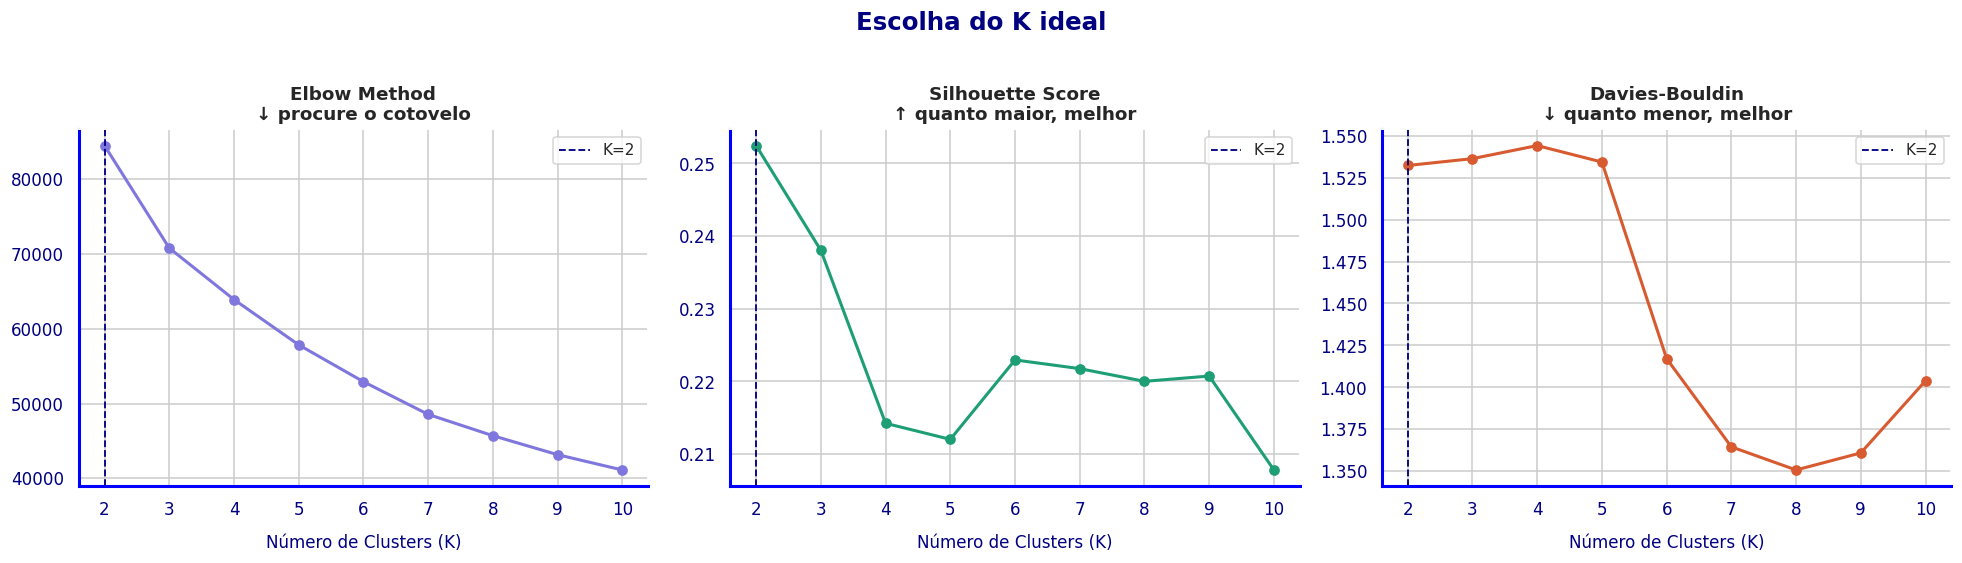

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (inertias,   '#7F77DD', 'Elbow Method',     '↓ procure o cotovelo'),
    (silhouettes,'#1D9E75', 'Silhouette Score',  '↑ quanto maior, melhor'),
    (db_scores,  '#D85A30', 'Davies-Bouldin',    '↓ quanto menor, melhor'),
]

for ax, (y, color, title, sub) in zip(axes, configs):
    ax.plot(K_range, y, 'o-', color=color, linewidth=2, markersize=6)
    ax.axvline(k_ideal, color='navy', linestyle='--',
               linewidth=1.2, label=f'K={k_ideal}')
    ax.set_title(f'{title}\n{sub}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Número de Clusters (K)', labelpad=10, size=11)
    ax.set_xticks(list(K_range))
    ax.legend(fontsize=10)
    ax.spines['bottom'].set_color('blue')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.spines['left'].set_color('blue')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(colors='navy', which='both')
    ax.xaxis.label.set_color('navy')
    ax.yaxis.label.set_color('navy')

plt.suptitle('Escolha do K ideal', fontsize=16,
             color='navy', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Escolha do K — Três métricas**

| Métrica | O que mede | Como interpretar |
|---------|-----------|------------------|
| **Elbow (Inércia)** | Soma das distâncias ao centroide | Cotovelo na curva = K ideal |
| **Silhouette Score** | Coesão interna vs separação entre clusters | Pico = K ideal |
| **Davies-Bouldin** | Razão dispersão interna / distância entre centroides | Mínimo = K ideal |

> **K escolhido:** `k_ideal` definido pelo maior Silhouette Score — critério mais robusto para dados sem estrutura conhecida.

In [20]:
km_final = KMeans(n_clusters=k_ideal, init='k-means++', random_state=42, n_init=10)
labels   = km_final.fit_predict(X_pca)

df_clean['cluster'] = labels

dist = df_clean['cluster'].value_counts().sort_index()
display(pd.DataFrame({
    'Cluster'    : dist.index,
    'Clientes'   : dist.values,
    '% do total' : (dist.values / len(df_clean) * 100).round(1)
}))


,Cluster,Clientes,% do total
0,0,5415,60.5
1,1,3535,39.5


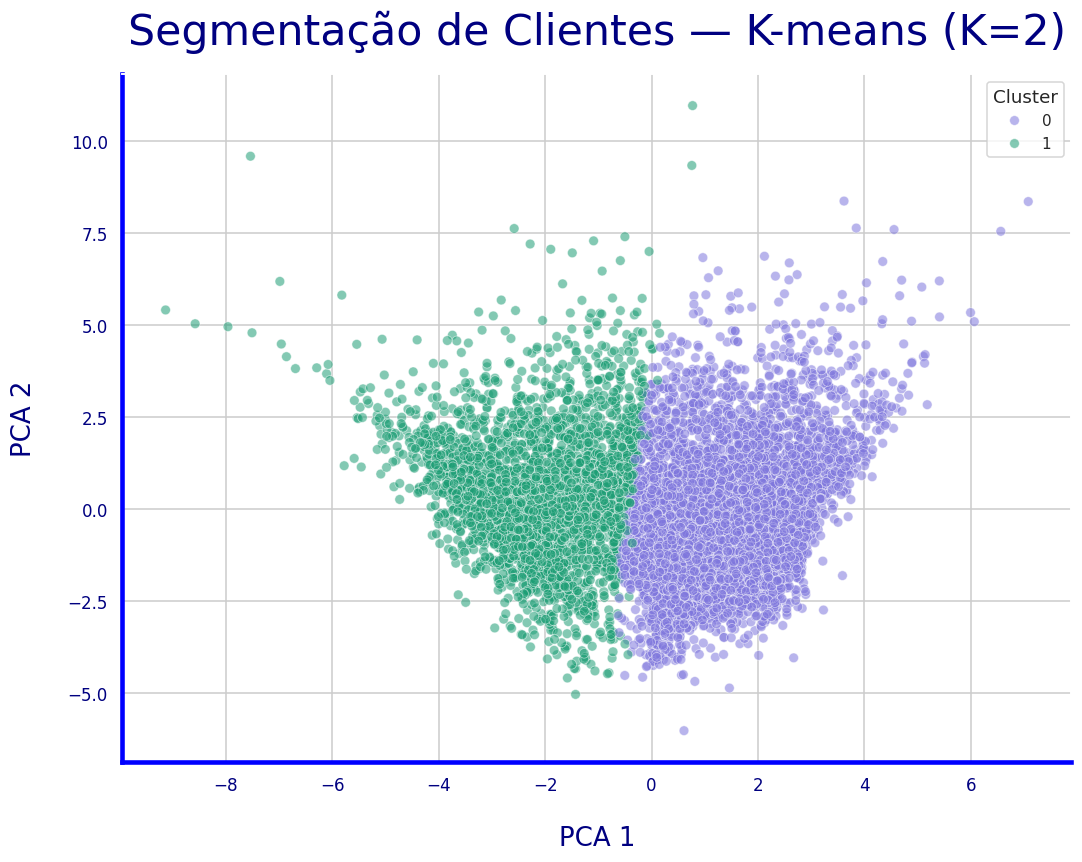

In [21]:
df_pca2 = pd.concat(
    [pca_2, pd.DataFrame({'cluster': labels})],
    axis=1
)

palette1 = dict(zip(
    sorted(df_pca2['cluster'].unique()),
    PALETA[:df_pca2['cluster'].nunique()]
))

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=df_pca2,
    palette=palette1,
    alpha=0.55, s=40
)
plt.title(f'Segmentação de Clientes — K-means (K={k_ideal})',
          fontsize=28, color='navy', y=1.03)
plt.xlabel('PCA 1', labelpad=20, size=17)
plt.ylabel('PCA 2', labelpad=20, size=17)
ax.spines['bottom'].set_color('blue')
ax.spines['top'].set_color('white')
ax.spines['right'].set_color('white')
ax.spines['left'].set_color('blue')
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.xaxis.label.set_color('navy')
ax.yaxis.label.set_color('navy')
ax.tick_params(colors='navy', which='both')
plt.legend(title='Cluster', title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.show()


**PCA — Clusters K-means**

Cada ponto é um cliente projetado nos dois primeiros componentes principais; a cor indica o cluster.

- Regiões bem separadas por cor indicam perfis comportamentais distintos
- Sobreposições parciais são esperadas: o K-means operou com `n_80` componentes (88% da variância), mas a visualização comprime tudo em 2 dimensões, perdendo parte da separação real

> A qualidade dos clusters é avaliada pelas métricas na Fase 5 — não pela separação visual aqui.

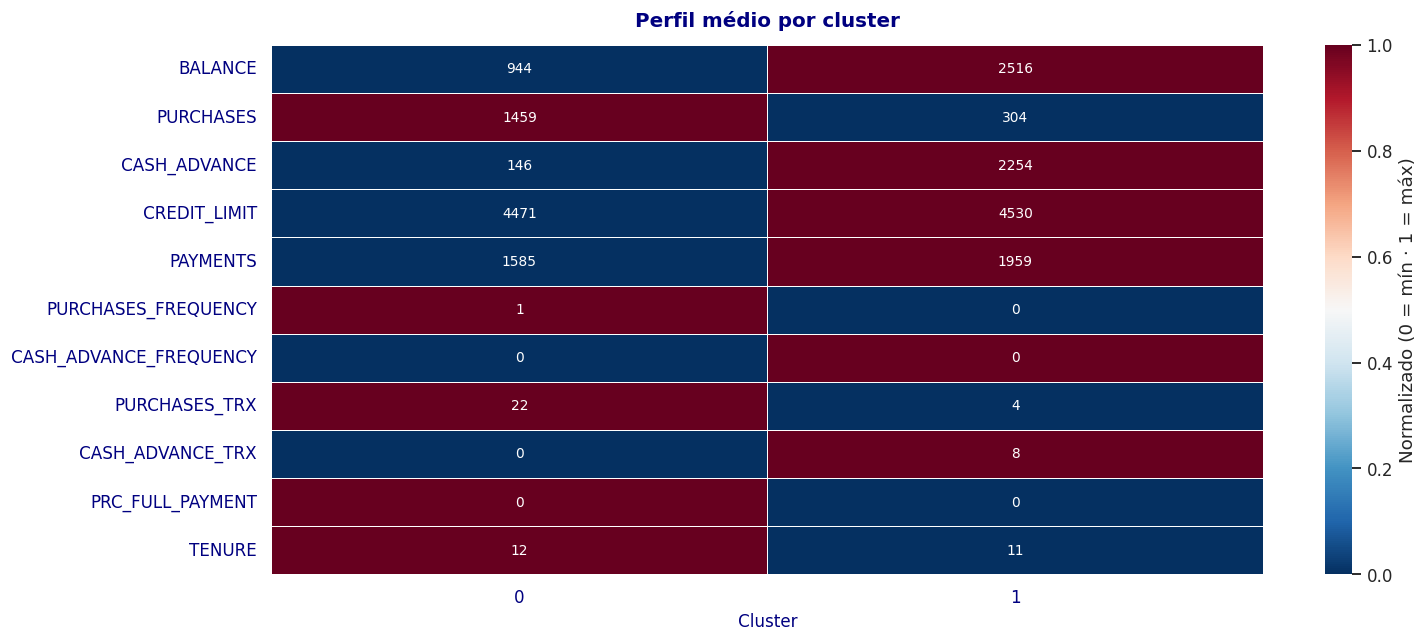

In [22]:
VARS_PERFIL = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
    'PAYMENTS', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
    'PURCHASES_TRX', 'CASH_ADVANCE_TRX', 'PRC_FULL_PAYMENT', 'TENURE'
]

perfil      = df_clean.groupby('cluster')[VARS_PERFIL].mean().round(1)
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    perfil_norm.T,
    annot=perfil.T, fmt='.0f',
    cmap='RdBu_r', center=0.5,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Normalizado (0 = mín · 1 = máx)'}
)
ax.set_title('Perfil médio por cluster',
             fontsize=13, fontweight='bold', pad=12, color='navy')
ax.set_xlabel('Cluster', fontsize=11, color='navy')
ax.set_ylabel('')
ax.tick_params(colors='navy')
plt.tight_layout()
plt.show()


**Perfil dos clusters**

Linhas = variáveis · Colunas = clusters · Cores normalizadas (0 = menor entre clusters · 1 = maior) · Números = médias reais.

Leia coluna por coluna para identificar o comportamento dominante de cada cluster:

| Cor dominante | O que indica |
|---------------|--------------|
| Toda vermelha | Alto uso em tudo — cliente de alto valor ou alto risco |
| Toda azul | Baixo uso — cliente conservador, inativo ou novo |
| Mix vermelho-azul | Perfil específico — leia variável por variável |

> Use este heatmap como base para a Fase 6 — o padrão de cores por coluna define o perfil de negócio de cada cluster.

---
## Fase 5 — Avaliação

Métricas internas para avaliar a qualidade dos clusters sem rótulo verdadeiro.

In [23]:
sil = silhouette_score(X_pca, labels, sample_size=3000, random_state=42)
db  = davies_bouldin_score(X_pca, labels)

pd.DataFrame({
    'Métrica'    : ['K utilizado', 'Silhouette Score', 'Davies-Bouldin Score'],
    'Valor'      : [k_ideal, round(sil, 4), round(db, 4)],
    'Referência' : [
        '—',
        'Máx = 1.0  ·  quanto maior, mais coesos os clusters',
        'Mín = 0.0  ·  quanto menor, mais separados os clusters'
    ]
})


,Métrica,Valor,Referência
0,K utilizado,2.0000,—
1,Silhouette Score,0.2525,"Máx = 1.0 · quanto maior, mais coesos os clu..."
2,Davies-Bouldin Score,1.5323,"Mín = 0.0 · quanto menor, mais separados os ..."


---
## Fase 6 — Implantação

Para cada cluster, a análise segue quatro dimensões de negócio:

| Dimensão | O que avalia |
|----------|--------------|
| **Comportamento** | Como o cliente usa o cartão (compra, saca, paga) |
| **Risco** | Probabilidade de inadimplência ou uso predatório do crédito |
| **Valor** | Potencial de geração de receita para o banco |
| **Oportunidade** | Ação de marketing mais adequada para esse perfil |

In [24]:
def classificar_cluster(row, perfil):
    """Classifica cada cluster nas 4 dimensões: comportamento, risco, valor, oportunidade."""

    alta_advance   = row['CASH_ADVANCE']         > perfil['CASH_ADVANCE'].median()
    baixo_full_pay = row['PRC_FULL_PAYMENT']      < 0.15
    alta_compra    = row['PURCHASES_FREQUENCY']   > 0.7
    alto_volume    = row['PURCHASES']             > perfil['PURCHASES'].median()
    alto_limite    = row['CREDIT_LIMIT']          > perfil['CREDIT_LIMIT'].median()
    alto_saldo     = row['BALANCE']               > perfil['BALANCE'].median()
    cliente_novo   = row['TENURE']                <= 8

    if alta_advance and baixo_full_pay:
        return (
            'Alta dependência de saque, baixa taxa de pagamento integral',
            'ALTO — potencial inadimplência; uso do crédito como fonte de liquidez',
            'MÉDIO — gera receita de juros, mas com risco de perda',
            'Incentivar parcelamento para reduzir saque; oferecer renegociação preventiva e alertas de custo'
        )
    elif alta_compra and alto_volume and not alta_advance:
        return (
            'Alta frequência de compras, alto volume transacionado, sem uso de saque',
            'BAIXO — perfil de pagador ativo com uso saudável do crédito',
            'ALTO — alta geração de intercâmbio e potencial para produtos de parcelamento',
            'Fidelizar com cashback, aumento de limite e acesso a produtos premium'
        )
    elif row['PRC_FULL_PAYMENT'] > 0.4:
        return (
            'Pagamento integral frequente, uso regular do cartão como meio de pagamento',
            'BAIXO — menor geração de juros, mas risco de crédito mínimo',
            'MÉDIO-ALTO — cliente de qualidade; potencial para seguros e produtos de investimento',
            'Ofertar produtos de valor agregado: seguros, pontos, cartões de categoria superior'
        )
    elif alto_saldo and not alta_compra:
        return (
            'Alto saldo rotativo com baixa frequência de compras — usa o crédito mas não compra',
            'MÉDIO — saldo acumulado pode indicar dificuldade de quitação',
            'MÉDIO — receita de juros rotativos, mas risco de inadimplência no longo prazo',
            'Oferecer parcelamento do saldo com taxa reduzida para reduzir risco e manter cliente ativo'
        )
    elif alto_limite and not alto_volume:
        return (
            'Alto limite concedido com baixo uso — cartão subutilizado',
            'BAIXO — cliente qualificado pelo banco mas com baixo engajamento',
            'BAIXO-MÉDIO — potencial não explorado de receita',
            'Campanhas de ativação com benefício imediato (bônus de pontos, cashback no primeiro uso)'
        )
    elif cliente_novo:
        return (
            'Relacionamento recente, comportamento ainda em formação',
            'INCERTO — histórico curto dificulta avaliação de risco',
            'POTENCIAL — janela crítica para moldar o comportamento do cliente',
            'Onboarding ativo: educar sobre benefícios, incentivar primeiras compras, monitorar de perto'
        )
    else:
        return (
            'Uso moderado do cartão sem padrão dominante claro',
            'BAIXO-MÉDIO — perfil estável sem sinais de alerta',
            'MÉDIO — base sólida mas sem diferencial de valor',
            'Nutrir com comunicação regular e ofertas sazonais para aumentar frequência de uso'
        )


linhas = []
for c in sorted(df_clean['cluster'].unique()):
    row = perfil.loc[c]
    comportamento, risco, valor, oportunidade = classificar_cluster(row, perfil)
    n = dist[c]
    linhas.append({
        'Cluster'       : c,
        'Clientes'      : f'{n} ({n/len(df_clean)*100:.1f}%)',
        'Comportamento' : comportamento,
        'Risco'         : risco,
        'Valor'         : valor,
        'Oportunidade'  : oportunidade,
    })

perfis_df = pd.DataFrame(linhas).set_index('Cluster')
perfis_df


,Clientes,Comportamento,Risco,Valor,Oportunidade
Cluster,,,,,
0,5415 (60.5%),Uso moderado do cartão sem padrão dominante claro,BAIXO-MÉDIO — perfil estável sem sinais de alerta,MÉDIO — base sólida mas sem diferencial de valor,Nutrir com comunicação regular e ofertas sazon...
1,3535 (39.5%),"Alta dependência de saque, baixa taxa de pagam...",ALTO — potencial inadimplência; uso do crédito...,"MÉDIO — gera receita de juros, mas com risco d...",Incentivar parcelamento para reduzir saque; of...


---
## Conclusão de Negócio

A segmentação identificou perfis distintos de clientes com base em comportamento financeiro real. Cada cluster representa uma estratégia diferente para o banco:

**Redução de risco**  
Clientes com alta dependência de saque e baixo pagamento integral representam risco de inadimplência. Ações preventivas de renegociação e incentivo ao parcelamento reduzem a exposição da carteira.

**Fidelização de alto valor**  
Compradores ativos com alto volume transacionado são os clientes mais rentávei. Investir em retenção tem retorno direto na receita.

**Ativação de potencial subutilizado**  
Clientes com alto limite e baixo uso representam capacidade de receita não explorada. Campanhas de ativação com benefício imediato têm alta probabilidade de conversão nesse grupo.

**Onboarding de novos clientes**  
Os primeiros meses de relacionamento definem o padrão de uso do cartão. Investir em educação e primeiras experiências positivas aumenta o LTV (lifetime value) do cliente.

